In [41]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.model_selection import LeaveOneOut
from tqdm import tqdm

In [42]:
df = pd.read_csv("https://raw.githubusercontent.com/edgarsmdn/MLCE_book/main/references/mutagenicity_kNN.csv")
df

,Unnamed: 0,Id,CAS,SMILES,Status,Experimental value,Predicted value,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,0,1,100-00-5,O=[N+]([O-])c1ccc(cc1)Cl,Training,1,1,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,1,2,100-01-6,O=[N+]([O-])c1ccc(N)cc1,Training,1,1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,2,3,100-02-7,O=[N+]([O-])c1ccc(O)cc1,Training,0,1,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,3,4,100-11-8,O=[N+]([O-])c1ccc(cc1)CBr,Training,1,0,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,4,5,100-12-9,O=[N+]([O-])c1ccc(cc1)CC,Training,0,0,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5759,5759,5767,20395-16-8,O=C1N(C(=O)N(C(=O)N1CC=C)CC2OC2)CC=C,Training,1,0,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,5760,5768,34718-47-3,O=C(C(Br)(Br)Br)Cl,Training,1,1,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,5761,5769,43204-63-3,N(CCBr)CCBr,Training,1,1,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,5762,5770,52583-35-4,N#Cc2cc(cc(c2(N=Nc1ccc(cc1(NC(=O)C))N(CCOC)CCO...,Training,1,1,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


In [43]:
df["Experimental value"]

0       1
1       1
2       0
3       1
4       0
       ..
5759    1
5760    1
5761    1
5762    1
5763    1
Name: Experimental value, Length: 5764, dtype: int64

In [44]:
df.head(1)

,Unnamed: 0,Id,CAS,SMILES,Status,Experimental value,Predicted value,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,0,1,100-00-5,O=[N+]([O-])c1ccc(cc1)Cl,Training,1,1,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.2482


In [45]:
df_clean = df.drop(["Unnamed: 0",	"Id",	"CAS",	"SMILES"	,"Status"	,"Experimental value",	"Predicted value"	],axis=1)

In [46]:
X = df_clean

In [47]:
x = df_clean.iloc[:,0]
Y = df_clean.iloc[:,1]
c = df_clean.iloc[:,2]
s = df_clean.iloc[:,3]

In [48]:
x, Y

(0        52
 1        52
 2        52
 3        58
 4        58
        ... 
 5759    102
 5760     42
 5761     44
 5762    184
 5763     88
 Name: NumValenceElectrons, Length: 5764, dtype: int64,
 0       0.463602
 1       0.359544
 2       0.470728
 3       0.432586
 4       0.479785
           ...   
 5759    0.485090
 5760    0.495987
 5761    0.568556
 5762    0.264581
 5763    0.735392
 Name: qed, Length: 5764, dtype: float64)

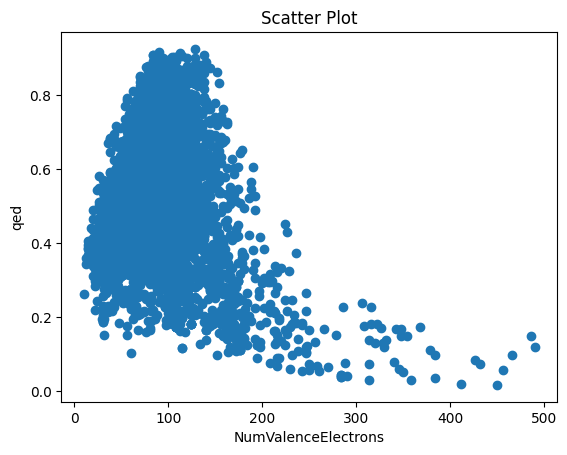

In [49]:
plt.scatter(x,Y)
plt.xlabel("NumValenceElectrons")
plt.ylabel("qed")
plt.title("Scatter Plot")
plt.show()

In [50]:
df_clean.dropna()

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...
5759,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


In [51]:
df_clean.dtypes

NumValenceElectrons      int64
qed                    float64
TPSA                   float64
MolMR                  float64
BalabanJ               float64
BertzCT                float64
MolWt                  float64
MolLogP                float64
dtype: object

In [52]:
df_clean[df_clean["NumValenceElectrons"]==490]

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
3311,490,0.117861,359.98,325.4772,1.320824,3416.975083,1255.438,0.72564


In [53]:
df_clean[df_clean["NumValenceElectrons"]==10]

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
1080,10,0.262188,19.9,3.9295,3.0,6.754888,28.01,-0.03751


In [54]:
df_clean[df_clean["NumValenceElectrons"].notnull()]

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...
5759,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


In [55]:
df.iloc[:,:3]

,Unnamed: 0,Id,CAS
0,0,1,100-00-5
1,1,2,100-01-6
2,2,3,100-02-7
3,3,4,100-11-8
4,4,5,100-12-9
...,...,...,...
5759,5759,5767,20395-16-8
5760,5760,5768,34718-47-3
5761,5761,5769,43204-63-3
5762,5762,5770,52583-35-4


In [56]:
df[df["Predicted value"]=="Non Predicted"].index

Index([1844, 2194, 4118, 4180, 5633, 5655], dtype='int64')

In [57]:
df_drop = df.drop(df[df["Predicted value"]=="Non Predicted"].index)

In [58]:
df_clean

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...
5759,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


In [59]:
y = df["Experimental value"].astype(int)
y

0       1
1       1
2       0
3       1
4       0
       ..
5759    1
5760    1
5761    1
5762    1
5763    1
Name: Experimental value, Length: 5764, dtype: int64

In [60]:
Mutagenic = int((y.sum()/len(y))*100)
Non_Mutagenic = 100 - Mutagenic
print(f'Percentage of Mutagenic compound:{Mutagenic}')
print(f'Percentage of Non Mutagenic compound:{Non_Mutagenic}')

Percentage of Mutagenic compound:56
Percentage of Non Mutagenic compound:44


In [61]:
x_train, x_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=0)

In [62]:
len(x_train), len(x_test)

(4611, 1153)

In [63]:
int(y_train.sum()), int(len(y_train) - y_train.sum()), int(y_test.sum()), int(len(y_test) - y_test.sum())

(2607, 2004, 644, 509)

In [64]:

scaler = StandardScaler()

In [65]:
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [66]:
x_train_scaled, x_test_scaled

(array([[ 2.12388901, -0.83189648,  1.47063519, ...,  1.66261095,
          2.59159212,  0.46980319],
        [ 1.37684535, -0.48094159, -1.10859929, ...,  0.65179722,
          1.13212837,  2.14274244],
        [ 2.2639597 , -2.34185166,  2.37715612, ...,  4.37012723,
          2.26927857,  1.29701729],
        ...,
        [ 0.30297007,  2.02079433,  0.35432342, ...,  0.69583677,
          0.67184179, -0.25015872],
        [ 0.25627984,  0.41726181,  0.19107481, ...,  0.90036826,
          0.19863991,  0.43622211],
        [-1.37787818,  0.18017205, -0.70375209, ..., -1.23541796,
         -0.36555537, -0.49353868]], shape=(4611, 8)),
 array([[ 1.65698672,  1.30330086,  0.48459488, ...,  0.33029692,
          1.2873879 ,  1.09234886],
        [-0.67752474,  0.94859064, -0.20231224, ..., -0.69094668,
         -0.621068  , -0.98750195],
        [-0.21062245, -1.19651722, -0.49606618, ..., -1.09156035,
         -0.47372319,  0.40004989],
        ...,
        [ 0.44304076, -1.22099156, -0

In [67]:
scaler.mean_

array([8.70221210e+01, 5.13332348e-01, 5.38802386e+01, 6.50020038e+01,
       2.57253915e+00, 5.19765923e+02, 2.41244465e+02, 2.57824068e+00])

In [68]:
scaler.scale_

array([4.28355146e+01, 1.66527409e-01, 4.27568726e+01, 3.08447128e+01,
       6.36481227e-01, 3.77691942e+02, 1.15986437e+02, 1.92965764e+00])

In [69]:
knn = KNeighborsClassifier(n_neighbors=3)

In [70]:
knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [71]:
y_pred = knn.predict(x_test_scaled)

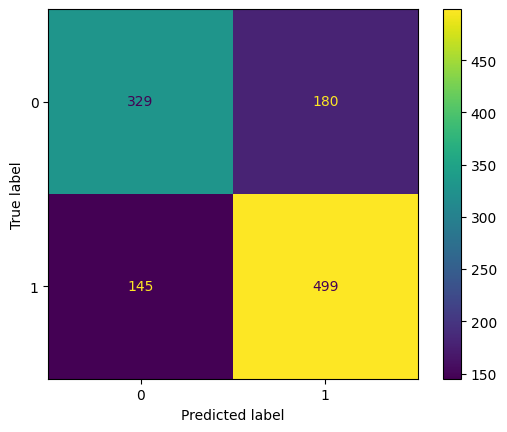

In [72]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [73]:
print(f'Accuracy Score: {accuracy_score(y_test, y_pred)}')
print(f'Precision Score: {precision_score(y_test, y_pred)}')
print(f'F1-Score: {f1_score(y_test, y_pred)}')

Accuracy Score: 0.7181266261925412
Precision Score: 0.7349042709867453
F1-Score: 0.7543461829176115


In [74]:
np.zeros(df_clean.shape[0])

array([0., 0., 0., ..., 0., 0., 0.], shape=(5764,))

In [75]:
L = LeaveOneOut()
print(f'Number of splits : {L.get_n_splits(X)}')

Number of splits : 5764


In [81]:
all_y_test = []
all_y_pred = []

for (train_index, test_index) in L.split(X):
  x_train_L = X.iloc[train_index]
  y_train_L = y.iloc[train_index]
  x_test_L = X.iloc[test_index]
  y_test_L = y.iloc[test_index]

  knn_L = KNeighborsClassifier(n_neighbors=4)
  knn_L.fit(x_train_L, y_train_L)
  y_pred_L = knn_L.predict(x_test_L)

  all_y_test.extend(y_test_L)
  all_y_pred.extend(y_pred_L)

Accuracy Score: 0.6384455239417072
Precision Score: 0.7171566803126163
F1-Score: 0.6490400808352981


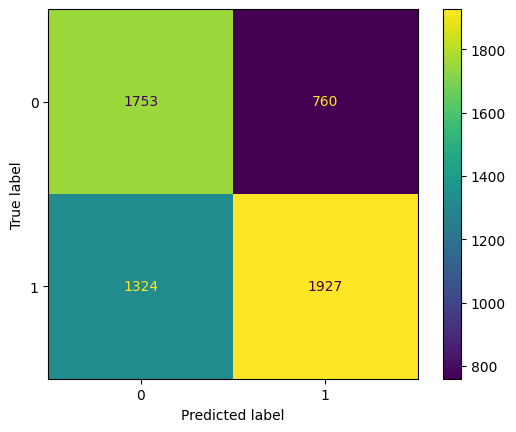

In [77]:
print(f'Accuracy Score: {accuracy_score(all_y_test, all_y_pred)}')
print(f'Precision Score: {precision_score(all_y_test, all_y_pred)}')
print(f'F1-Score: {f1_score(all_y_test, all_y_pred)}')
cm_L = confusion_matrix(all_y_test, all_y_pred)
disp_L = ConfusionMatrixDisplay(confusion_matrix=cm_L)
disp_L.plot()

In [78]:
hyp_K = np.arange(1,100,2).astype(int)
x_train_hyp, x_validation, y_train_hyp, y_validation = train_test_split(x_train_scaled, y_train, test_size=0.1, random_state=0)

train_misclassification = []
validation_misclassification = []

for i in tqdm(range(len(hyp_K))):
  knn_hyp = KNeighborsClassifier(n_neighbors= hyp_K[i])
  knn_hyp.fit(x_train_hyp, y_train_hyp)
  y_pred_train = knn_hyp.predict(x_train_hyp)
  y_pred_validation = knn_hyp.predict(x_validation)
  train_misclassification.append(1 - accuracy_score(y_train_hyp, y_pred_train))
  validation_misclassification.append(1 - accuracy_score(y_validation, y_pred_validation))

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:11<00:00,  4.35it/s]


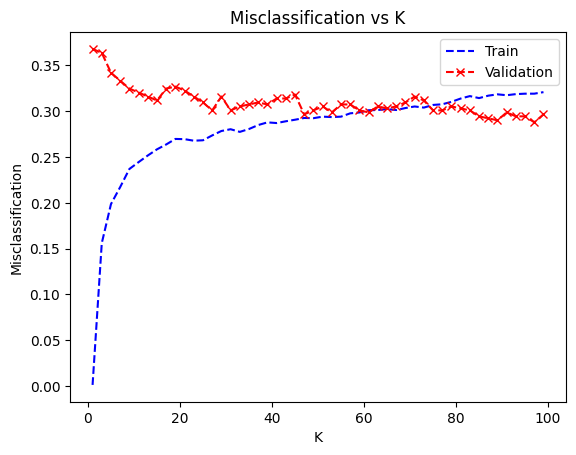

In [79]:
plt.figure()
plt.plot(hyp_K, train_misclassification,'b--')
plt.plot(hyp_K, validation_misclassification, 'rx--')
plt.plot()
plt.xlabel("K")
plt.ylabel("Misclassification")
plt.title("Misclassification vs K")
plt.legend(["Train", "Validation"])
plt.show()

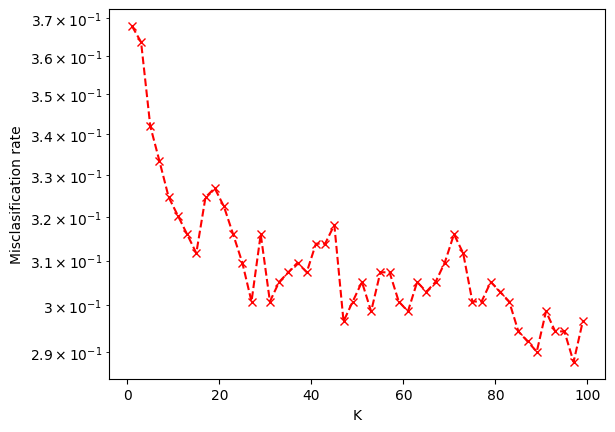

In [80]:
plt.figure()
plt.plot(hyp_K, validation_misclassification, 'rx--', label='Validation')
plt.yscale('log')
plt.xlabel('K')
plt.ylabel('Misclasification rate')
plt.show()